In [10]:
import gfapy
import networkx as nx
import numpy as np
from itertools import product
from dimod import BQM
from dwave.system import LeapHybridSampler
from math import floor
import re

In [3]:
def oriented_graph_from_file(filename):
    """Reads a .gfa file into an oriented graph.

    Args:
        filename (str): filepath to read.

    Returns:
        nx.Graph: corresponding oriented graph.
    """
    gfa = gfapy.Gfa.from_file(filename, vlevel=0)
    graph = nx.DiGraph()
    for segment_line in gfa.segments:
        graph.add_node(f'{segment_line.name}_+', sequence=segment_line.sequence, weight=segment_line.SC, start=segment_line.st)
        graph.add_node(f'{segment_line.name}_-', sequence=segment_line.sequence, weight=segment_line.SC, start=segment_line.st)
    for edge_line in gfa.edges:
        v1 = edge_line.sid1
        v2 = edge_line.sid2
        graph.add_edges_from([
            (f'{v1.name}_{v1.orient}', f'{v2.name}_{v2.orient}'),
        ])
        v1.invert()
        v2.invert()
        graph.add_edges_from([
            (f'{v2.name}_{v2.orient}', f'{v1.name}_{v1.orient}'),
        ])
    return graph

In [4]:
def normalise_node_weights(graph, normalisation):
    for node in graph.nodes:
        graph.nodes[node]["weight"] = round(graph.nodes[node]["weight"] / normalisation)
    return graph

In [14]:
# g = oriented_graph_from_file('../../data/test.gfa')
g = oriented_graph_from_file('../../data/ddDapMeze1.MT.k101.utg.final.gfa')
g = normalise_node_weights(g, 100)

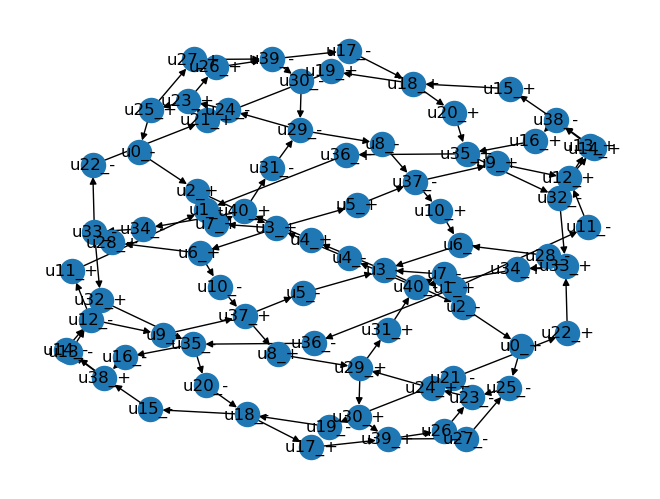

In [15]:
nx.draw_kamada_kawai(g, with_labels=True)

In [16]:
nodes = list(g.nodes)
V = int(len(nodes) / 2)
total_weight = int(sum(g.nodes[node]["weight"] for node in nodes) / 2)
alpha = 1.2
T_max = int(total_weight * alpha)

lambda_t = 4
lambda_g = 2
lambda_w = 1 

In [17]:
qubo_matrix = np.zeros((T_max, V + 1, 2, T_max, V + 1, 2))

# Path constraint
for t in range(T_max):
    for i in range(V):
        for b in range(2):
            qubo_matrix[t, i, b, t, i, b] -= lambda_t
            qubo_matrix[t, V, 0, t, i, b] += 2 * lambda_t
    qubo_matrix[t, V, 0, t, V, 0] -= lambda_t
    
    for i, j, bi, bj in product(range(V), range(V), range(2), range(2)):
        if not (i == j and bi == bj):
            qubo_matrix[t, i, bi, t, j, bj] += lambda_t

# Graph step constraints
for t in range(T_max - 1):
    for i, j, bi, bj in product(range(V), range(V), range(2), range(2)):
        if not (nodes[2 * i + bi], nodes[2 * j + bj]) in g.edges:
            qubo_matrix[t, i, bi, t+1, j, bj] += lambda_g
    for i, bi in product(range(V), range(2)):
        qubo_matrix[t, V, 0, t+1, i, bi] += lambda_g
            
# Weights constraints
for i in range(V):
    for t in range(T_max):
        for b in range(2):
            qubo_matrix[t, i, b, t, i, b] -= (2 * g.nodes[nodes[2 * i]]["weight"] - 1) * lambda_w
    
    for t1, t2 in product(range(T_max), range(T_max)):
        for b1, b2 in product(range(2), range(2)):
            if not (t1 == t2 and b1 == b2):
                qubo_matrix[t1, i, b1, t2, i, b2] += lambda_w


In [22]:

qubo_matrix = qubo_matrix.reshape((T_max * (V+1) * 2), (T_max * (V+1) * 2))
qubo_matrix = 0.5 * (qubo_matrix + qubo_matrix.T)

print(qubo_matrix[np.ravel_multi_index((2, V, 1), dims=(T_max, V+1, 2)), :])
print(qubo_matrix[:, np.ravel_multi_index((2, V, 1), dims=(T_max, V+1, 2))])
# Delete excess rows and columns
qubo_matrix = np.delete(qubo_matrix, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 0)
qubo_matrix = np.delete(qubo_matrix, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 1)

[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]


In [29]:
bqm = BQM(qubo_matrix, 'BINARY')
bqm.offset = lambda_t * T_max  + lambda_w * int(sum(g.nodes[nodes[2 * i]]["weight"] ** 2 for i in range(V)))
bqm.offset

31.0

In [30]:
print(bqm.num_variables)
print(bqm.num_interactions)
print(max(bqm.degrees().values()))
print(np.max(qubo_matrix))
print(np.min(qubo_matrix))

54
686
29
5.0
-7.0


In [22]:
# Upper bound for num interactions - TODO: not actually an UB
T_max * (2 + 6 * V + 4 * V ** 2 + 4 * T_max + len(g.edges))

45888

In [ ]:
sample = sampleset.first.sample
energy = sampleset.first.energy
print(energy)
sample_list = np.array(list(sample.values()))
sample_list_copy = np.copy(sample_list)
for idx in [t * (V+1) *2 + V * 2 + 1 for t in range(T_max)]:
    sample_list_copy = np.insert(sample_list_copy, idx, 0)
sample_array = sample_list_copy.reshape((T_max, V + 1, 2))

30.0


In [ ]:
test_sample = np.zeros_like(sample_array)
test_sample[0, 0, 0] = 1
test_sample[1, 1, 0] = 1
test_sample[2, 2, 0] = 1
test_sample[3, 3, 0] = 1
test_sample[4, 0, 0] = 1
test_sample[5, 4, 0] = 1
test_sample_list = test_sample.reshape(T_max * (V + 1) * 2)
for idx in [t * (V+1) *2 + V * 2 + 1 for t in range(T_max -1, -1, -1)]:
    test_sample_list = np.delete(test_sample_list, idx, 0)

In [ ]:
test_sample_list @ qubo_matrix @ test_sample_list + lambda_t * T_max  + lambda_w * int(sum(g.nodes[nodes[2 * i]]["weight"] ** 2 for i in range(V)))

-29.0

In [ ]:
sample_list @ qubo_matrix @ sample_list + lambda_t * T_max  + lambda_w * int(sum(g.nodes[nodes[2 * i]]["weight"] ** 2 for i in range(V)))

30.0

In [23]:
hybrid_sampler = LeapHybridSampler()
hybrid_sampleset = hybrid_sampler.sample(bqm, label="Oriented Tangle Testing")

In [313]:
hybrid_sample = hybrid_sampleset.first.sample
hybrid_energy = hybrid_sampleset.first.energy
hybrid_sample_list = np.array(list(hybrid_sample.values()))
hybrid_sample_list_copy = np.copy(hybrid_sample_list)
for idx in [t * (V+1) *2 + V * 2 + 1 for t in range(T_max)]:
    hybrid_sample_list_copy = np.insert(hybrid_sample_list_copy, idx, 0)
hybrid_sample_array = hybrid_sample_list_copy.reshape((T_max, V + 1, 2))

In [19]:
def array_to_path(arr):
    nz = np.nonzero(arr == 1)
    return [(nz[0][i], nz[1][i], nz[2][i]) for i in range(nz[0].shape[0])]
        

In [314]:
print(array_to_path(sample_array))
print(array_to_path(test_sample))
print(array_to_path(hybrid_sample_array))

[(0, 3, 1), (1, 1, 0), (2, 2, 1), (3, 2, 1), (4, 1, 1), (5, 0, 0)]
[(0, 0, 0), (1, 1, 0), (2, 2, 0), (3, 3, 0), (4, 0, 0), (5, 4, 0)]
[(0, 0, 0), (1, 1, 0), (2, 2, 0), (3, 3, 0), (4, 0, 0), (5, 4, 0)]


In [29]:
# k501 path
# best_path_nodes = ['u5-','u3-','u0-','u2+','u9+','u6-','u5+','u4-','u0-','u2+','u9+','u11+','u15+','u16+','u14-','u13-','u12+','u11-','u9-','u2-','u1+','u13-','u10-','u9-','u8+','u16-','u7-', 'u5-']

# k101 path
best_path_nodes = ["u21+","u23+","u25+","u27+","u39-","u30-","u29-","u24-","u23+","u25+","u0-","u2+","u3+","u6+","u10-","u37+","u5-","u3-","u2-","u1+","u11-","u12+","u14+","u38-","u16+","u35+","u32-","u33+","u34+","u40-","u7-","u3-","u2-","u1+","u36-","u35-","u20-","u18-","u17+","u39+","u26-","u23-","u21-","u19-","u18-","u15-","u38+","u13-","u12-","u9-","u37+","u8+","u29+","u31+","u40-","u4-","u3+","u6+","u28+","u33-","u22-"]


best_path_sample = np.zeros((T_max, V+1, 2))
for i in range(len(best_path_nodes)):
    node_matches = re.search(
        r'(.+)([\+\-])',
        best_path_nodes[i]
    )
    node_name = f"{node_matches[1]}_{node_matches[2]}"
    best_path_sample[i, floor(nodes.index(node_name) /2), nodes.index(node_name) % 2] = 1
best_path_sample[i+1:, -1, 0] = 1
print(array_to_path(best_path_sample))

[(0, 21, 0), (1, 23, 0), (2, 25, 0), (3, 27, 0), (4, 39, 1), (5, 30, 1), (6, 29, 1), (7, 24, 1), (8, 23, 0), (9, 25, 0), (10, 0, 1), (11, 2, 0), (12, 3, 0), (13, 6, 0), (14, 10, 1), (15, 37, 0), (16, 5, 1), (17, 3, 1), (18, 2, 1), (19, 1, 0), (20, 11, 1), (21, 12, 0), (22, 14, 0), (23, 38, 1), (24, 16, 0), (25, 35, 0), (26, 32, 1), (27, 33, 0), (28, 34, 0), (29, 40, 1), (30, 7, 1), (31, 3, 1), (32, 2, 1), (33, 1, 0), (34, 36, 1), (35, 35, 1), (36, 20, 1), (37, 18, 1), (38, 17, 0), (39, 39, 0), (40, 26, 1), (41, 23, 1), (42, 21, 1), (43, 19, 1), (44, 18, 1), (45, 15, 1), (46, 38, 0), (47, 13, 1), (48, 12, 1), (49, 9, 1), (50, 37, 0), (51, 8, 0), (52, 29, 0), (53, 31, 0), (54, 40, 1), (55, 4, 1), (56, 3, 0), (57, 6, 0), (58, 28, 0), (59, 33, 1), (60, 22, 1), (61, 41, 0), (62, 41, 0), (63, 41, 0), (64, 41, 0), (65, 41, 0), (66, 41, 0), (67, 41, 0), (68, 41, 0), (69, 41, 0), (70, 41, 0), (71, 41, 0), (72, 41, 0)]


In [30]:
best_sample = best_path_sample.reshape((T_max * (V+1) * 2),)
best_sample = np.delete(best_sample, [np.ravel_multi_index((t, V, 1), dims=(T_max, V+1, 2)) for t in range(T_max)], 0)


In [31]:
best_sample @ qubo_matrix @ best_sample

-403.0

In [27]:
offset = lambda_t * T_max  + lambda_w * int(sum(g.nodes[nodes[2 * i]]["weight"] ** 2 for i in range(V)))


In [28]:
offset

403